# IPL 2026 Match Winner Prediction

**Goal:** Predict which team wins an IPL match given: teams, venue, toss info, and playing XI.

**Steps:**
1. Load data
2. Extract playing XI from cricsheet
3. Engineer features (Elo, form, H2H, venue, toss, player strength)
4. Train XGBoost model
5. Evaluate & save

In [1]:
# ============================================================
# Step 1: Imports
# ============================================================
import pandas as pd
import numpy as np
import json
import zipfile
import pickle
import os
import warnings
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

print("All imports loaded!")

All imports loaded!


## Step 2: Load Data

In [2]:
# ============================================================
# Step 2: Load all datasets
# ============================================================
DATA_DIR = 'Datasets'

matches = pd.read_csv(f'{DATA_DIR}/matches.csv')
player_ipl = pd.read_csv(f'{DATA_DIR}/player_ipl_stats.csv')
player_lifetime = pd.read_csv(f'{DATA_DIR}/player_lifetime_stats.csv')
players_meta = pd.read_csv(f'{DATA_DIR}/players-data-updated.csv')
team_aliases = pd.read_csv(f'{DATA_DIR}/team_aliases.csv')

print(f"Matches: {len(matches)} rows")
print(f"Player IPL stats: {len(player_ipl)} players")
print(f"Player lifetime stats: {len(player_lifetime)} players")
print(f"Team aliases: {len(team_aliases)} entries")
print(f"\nMatches columns: {list(matches.columns)}")
matches.head(3)

Matches: 1169 rows
Player IPL stats: 767 players
Player lifetime stats: 772 players
Team aliases: 46 entries

Matches columns: ['match_id', 'season_id', 'balls_per_over', 'city', 'date', 'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs', 'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'result']


,match_id,season_id,balls_per_over,city,date,event_name,match_number,gender,match_type,format,overs,season,team_type,venue,toss_winner,team1,team2,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match,result
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,20,2008,club,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Royal Challengers Bengaluru,Kolkata Knight Riders,field,Kolkata Knight Riders,140.0,NaN,46.0,win
1,1082591,2017,6,Hyderabad,2017-04-05,Indian Premier League,1.0,male,T20,T20,20,2017,club,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,Sunrisers Hyderabad,Royal Challengers Bengaluru,field,Sunrisers Hyderabad,35.0,NaN,15.0,win
2,1082592,2017,6,Pune,2017-04-06,Indian Premier League,2.0,male,T20,T20,20,2017,club,Maharashtra Cricket Association Stadium,Rising Pune Supergiants,Rising Pune Supergiants,Mumbai Indians,field,Rising Pune Supergiants,NaN,7.0,36.0,win


## Step 3: Team Name Normalization

Team names change across seasons (e.g., "Delhi Daredevils" â†’ "Delhi Capitals", "Kings XI Punjab" â†’ "Punjab Kings"). We map everything to a canonical short code using `team_aliases.csv`.

In [3]:
# ============================================================
# Step 3: Build team name normalizer
# ============================================================

# Build a lookup: "Delhi Daredevils" -> "DC", "Kings XI Punjab" -> "PK", etc.
alias_map = {}
for _, row in team_aliases.iterrows():
    alias_map[row['alias_name'].strip().lower()] = row['team_alias'].strip()

def normalize_team(name):
    """Convert any team name variant to its canonical short code."""
    if pd.isna(name):
        return name
    return alias_map.get(name.strip().lower(), name.strip())

# Normalize all team columns in matches
matches['team1'] = matches['team1'].apply(normalize_team)
matches['team2'] = matches['team2'].apply(normalize_team)
matches['winner'] = matches['winner'].apply(normalize_team)
matches['toss_winner'] = matches['toss_winner'].apply(normalize_team)

# Remove matches with no result (ties, no result, etc.)
matches = matches[matches['result'] == 'win'].reset_index(drop=True)

print(f"Matches after removing no-results: {len(matches)}")
print(f"Unique teams: {sorted(matches['team1'].unique())}")

Matches after removing no-results: 1146
Unique teams: ['CSK', 'DC', 'GL', 'GT', 'KKR', 'KTK', 'LSG', 'MI', 'PK', 'PW', 'RCB', 'RPS', 'RR', 'SRH']


## Step 4: Extract Playing XI from Cricsheet

The cricsheet zip has JSON files for every IPL match, each containing the full playing XI. We extract this and attach it to our matches dataframe.

In [4]:
# ============================================================
# Step 4: Parse cricsheet zip to get playing XI per match
# ============================================================

ZIP_PATH = f'{DATA_DIR}/cricsheet_cache/all_male_json.zip'

# Parse all IPL matches from the zip
# Key = match_id (filename without .json), Value = {team_code: [player_names]}
playing_xi_data = {}

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for filename in z.namelist():
        if not filename.endswith('.json'):
            continue
        
        data = json.loads(z.read(filename))
        info = data.get('info', {})
        
        # Only IPL matches
        event_name = info.get('event', {}).get('name', '')
        if 'Indian Premier League' not in event_name:
            continue
        
        match_id = int(filename.replace('.json', ''))
        players = info.get('players', {})
        
        # Normalize team names and store XI
        xi = {}
        for team_name, player_list in players.items():
            team_code = normalize_team(team_name)
            xi[team_code] = player_list
        
        playing_xi_data[match_id] = xi

print(f"Extracted playing XI for {len(playing_xi_data)} IPL matches")

# Show one example
sample_id = list(playing_xi_data.keys())[0]
print(f"\nExample (match {sample_id}):")
for team, xi in playing_xi_data[sample_id].items():
    print(f"  {team}: {xi[:3]}... ({len(xi)} players)")

Extracted playing XI for 1169 IPL matches

Example (match 1082591):
  RCB: ['CH Gayle', 'Mandeep Singh', 'TM Head']... (11 players)
  SRH: ['DA Warner', 'S Dhawan', 'MC Henriques']... (11 players)


## Step 5: Build Player Stats Lookup

We need to quickly look up any player's batting/bowling stats. We use IPL stats first, and fall back to lifetime T20 stats for uncapped players.

In [5]:
# ============================================================
# Step 5: Build player stats lookup
# ============================================================

# IPL stats lookup: player name -> stats dict
ipl_stats = {}
for _, row in player_ipl.iterrows():
    ipl_stats[row['player']] = {
        'batting_sr': row['batting_sr'] if pd.notna(row['batting_sr']) else 0,
        'bowling_econ': row['bowling_econ'] if pd.notna(row['bowling_econ']) else 0,
        'experience': row['ipl_experience'] if pd.notna(row['ipl_experience']) else 0,
        'avg_runs': row['avg_runs'] if pd.notna(row['avg_runs']) else 0,
        'boundary_pct': row['boundary_pct'] if pd.notna(row['boundary_pct']) else 0,
    }

# Lifetime stats lookup (fallback): player name -> stats dict
lifetime_stats = {}
for _, row in player_lifetime.iterrows():
    lifetime_stats[row['player_name']] = {
        'batting_sr': row['overall_batting_sr'] if pd.notna(row['overall_batting_sr']) else 0,
        'bowling_econ': row['overall_bowling_econ'] if pd.notna(row['overall_bowling_econ']) else 0,
        'experience': row['overall_matches'] if pd.notna(row['overall_matches']) else 0,
        'avg_runs': row['overall_batting_avg'] if pd.notna(row['overall_batting_avg']) else 0,
        'boundary_pct': 0,  # not available in lifetime stats
    }

# Default stats for completely unknown players
DEFAULT_STATS = {
    'batting_sr': 120.0,
    'bowling_econ': 8.0,
    'experience': 0,
    'avg_runs': 20.0,
    'boundary_pct': 0.5,
}

def get_player_stats(player_name):
    """Look up player stats: IPL first, then lifetime, then defaults."""
    if player_name in ipl_stats:
        return ipl_stats[player_name]
    if player_name in lifetime_stats:
        return lifetime_stats[player_name]
    return DEFAULT_STATS.copy()

# Test it
print("V Kohli:", get_player_stats('V Kohli'))
print("Rashid Khan:", get_player_stats('Rashid Khan'))
print("Unknown Player:", get_player_stats('Unknown Player'))

V Kohli: {'batting_sr': 129.3792898, 'bowling_econ': 8.431818182, 'experience': 259, 'avg_runs': 33.47876448, 'boundary_pct': 0.559105063}
Rashid Khan: {'batting_sr': 151.1627907, 'bowling_econ': 7.160333642, 'experience': 136, 'avg_runs': 8.863636364, 'boundary_pct': 0.700854701}
Unknown Player: {'batting_sr': 120.0, 'bowling_econ': 8.0, 'experience': 0, 'avg_runs': 20.0, 'boundary_pct': 0.5}


## Step 6: Feature Engineering Functions

We compute features **match by match in chronological order**, so each match only uses data from matches played *before* it.

**Features we'll compute:**
1. **Elo ratings** â€” rolling team strength (starts at 1500, updates after each match)
2. **Team form** â€” win rate in last 5 matches
3. **Head-to-head** â€” historical win rate between the two teams
4. **Venue stats** â€” bat-first win %, each team's win % at this venue
5. **Toss features** â€” who won toss, what they chose
6. **Player strength** â€” average batting SR, bowling economy, experience of the XI
7. **Home advantage** â€” is the team playing at their home ground

In [6]:
# ============================================================
# Step 6: Feature engineering functions
# ============================================================

# --- 6a: Elo Rating System ---
# Each team starts at 1500. Winner gains points, loser loses points.
# K-factor = 32 (how much a single match matters)

def update_elo(winner_elo, loser_elo, k=32):
    """Calculate new Elo ratings after a match."""
    expected_win = 1 / (1 + 10 ** ((loser_elo - winner_elo) / 400))
    new_winner = winner_elo + k * (1 - expected_win)
    new_loser = loser_elo + k * (0 - (1 - expected_win))
    return new_winner, new_loser


# --- 6b: Team Form ---
# Win rate in the last N matches for a team

def get_team_form(team, match_history, n=5):
    """Get win rate in last N matches for a team."""
    team_matches = [m for m in match_history if m['team1'] == team or m['team2'] == team]
    recent = team_matches[-n:]  # last N
    if len(recent) == 0:
        return 0.5  # no history = neutral
    wins = sum(1 for m in recent if m['winner'] == team)
    return wins / len(recent)


# --- 6c: Head-to-Head ---

def get_h2h(team1, team2, match_history):
    """Get team1's win rate against team2 from history."""
    h2h_matches = [
        m for m in match_history
        if (m['team1'] == team1 and m['team2'] == team2) or
           (m['team1'] == team2 and m['team2'] == team1)
    ]
    if len(h2h_matches) == 0:
        return 0.5  # no history
    team1_wins = sum(1 for m in h2h_matches if m['winner'] == team1)
    return team1_wins / len(h2h_matches)


# --- 6d: Venue Stats ---

def get_venue_stats(team, venue, match_history):
    """Get team's win rate at this venue, and bat-first win % at venue."""
    venue_matches = [m for m in match_history if m['venue'] == venue]
    
    # Team's win rate at venue
    team_venue = [m for m in venue_matches if m['team1'] == team or m['team2'] == team]
    if len(team_venue) > 0:
        team_venue_wr = sum(1 for m in team_venue if m['winner'] == team) / len(team_venue)
    else:
        team_venue_wr = 0.5
    
    # Bat-first win % at venue
    if len(venue_matches) > 0:
        bat_first_wins = sum(
            1 for m in venue_matches
            if m['toss_decision'] == 'bat' and m['toss_winner'] == m['winner']
            or m['toss_decision'] == 'field' and m['toss_winner'] != m['winner']
        )
        bat_first_pct = bat_first_wins / len(venue_matches)
    else:
        bat_first_pct = 0.5
    
    return team_venue_wr, bat_first_pct


# --- 6e: Player Strength ---

def get_team_strength(team_code, match_id, playing_xi_data):
    """Compute average player stats for a team's XI in a specific match."""
    xi_dict = playing_xi_data.get(match_id, {})
    players = xi_dict.get(team_code, [])
    
    if len(players) == 0:
        return DEFAULT_STATS.copy()
    
    stats_list = [get_player_stats(p) for p in players]
    
    return {
        'batting_sr': np.mean([s['batting_sr'] for s in stats_list]),
        'bowling_econ': np.mean([s['bowling_econ'] for s in stats_list]),
        'experience': np.mean([s['experience'] for s in stats_list]),
        'avg_runs': np.mean([s['avg_runs'] for s in stats_list]),
    }


# --- 6f: Home Advantage ---

HOME_GROUNDS = {
    'MI': 'Wankhede Stadium',
    'CSK': 'MA Chidambaram Stadium',
    'RCB': 'M Chinnaswamy Stadium',
    'KKR': 'Eden Gardens',
    'DC': 'Arun Jaitley Stadium',
    'SRH': 'Rajiv Gandhi International Stadium',
    'RR': 'Sawai Mansingh Stadium',
    'PK': 'Maharaja Yadavindra Singh Stadium',
    'LSG': 'BRSABV Ekana Cricket Stadium',
    'GT': 'Narendra Modi Stadium',
}

SECONDARY_GROUNDS = {
    'RCB': 'Shaheed Veer Narayan Singh International Cricket Stadium',
    'PK': 'HPCA Cricket Stadium',
    'RR': 'ACA Cricket Stadium',
}

def is_home(team, venue):
    """Check if venue is this team's home ground (including secondary)."""
    home = HOME_GROUNDS.get(team, '')
    secondary = SECONDARY_GROUNDS.get(team, '')
    venue_l = venue.lower()
    if home and home.lower() in venue_l:
        return 1
    if secondary and secondary.lower() in venue_l:
        return 1
    return 0

print("All feature functions ready!")


All feature functions ready!


## Step 7: Build Feature Matrix

Loop through every match **in date order**. For each match:
- Compute all features using only past match data
- After computing features, add this match to history (so future matches can use it)
- Update Elo ratings after the match

In [7]:
# ============================================================
# Step 7: Build the feature matrix
# ============================================================

# Sort matches by date
matches['date'] = pd.to_datetime(matches['date'])
matches = matches.sort_values('date').reset_index(drop=True)

# Initialize trackers
elo_ratings = defaultdict(lambda: 1500)  # every team starts at 1500
match_history = []  # grows as we process matches
features_list = []

for idx, row in matches.iterrows():
    team1 = row['team1']
    team2 = row['team2']
    venue = row['venue']
    winner = row['winner']
    toss_winner = row['toss_winner']
    toss_decision = row['toss_decision']
    match_id = row['match_id']
    
    # --- Elo ---
    team1_elo = elo_ratings[team1]
    team2_elo = elo_ratings[team2]
    
    # --- Form ---
    team1_form = get_team_form(team1, match_history, n=5)
    team2_form = get_team_form(team2, match_history, n=5)
    
    # --- Head to Head ---
    h2h_team1_wr = get_h2h(team1, team2, match_history)
    
    # --- Venue ---
    team1_venue_wr, bat_first_pct = get_venue_stats(team1, venue, match_history)
    team2_venue_wr, _ = get_venue_stats(team2, venue, match_history)
    
    # --- Toss ---
    toss_winner_is_team1 = 1 if toss_winner == team1 else 0
    toss_chose_bat = 1 if toss_decision == 'bat' else 0
    
    # --- Home Advantage ---
    team1_home = is_home(team1, venue)
    team2_home = is_home(team2, venue)
    
    # --- Player Strength ---
    t1_strength = get_team_strength(team1, match_id, playing_xi_data)
    t2_strength = get_team_strength(team2, match_id, playing_xi_data)
    
    # --- Target ---
    team1_wins = 1 if winner == team1 else 0
    
    # Build feature row
    features_list.append({
        # Elo
        'team1_elo': team1_elo,
        'team2_elo': team2_elo,
        'elo_diff': team1_elo - team2_elo,
        
        # Form
        'team1_form': team1_form,
        'team2_form': team2_form,
        'form_diff': team1_form - team2_form,
        
        # Head to Head
        'h2h_team1_wr': h2h_team1_wr,
        
        # Venue
        'team1_venue_wr': team1_venue_wr,
        'team2_venue_wr': team2_venue_wr,
        'bat_first_pct': bat_first_pct,
        
        # Toss
        'toss_winner_is_team1': toss_winner_is_team1,
        'toss_chose_bat': toss_chose_bat,
        
        # Home
        'team1_home': team1_home,
        'team2_home': team2_home,
        
        # Player Strength - Team 1
        'team1_bat_sr': t1_strength['batting_sr'],
        'team1_bowl_econ': t1_strength['bowling_econ'],
        'team1_experience': t1_strength['experience'],
        'team1_avg_runs': t1_strength['avg_runs'],
        
        # Player Strength - Team 2
        'team2_bat_sr': t2_strength['batting_sr'],
        'team2_bowl_econ': t2_strength['bowling_econ'],
        'team2_experience': t2_strength['experience'],
        'team2_avg_runs': t2_strength['avg_runs'],
        
        # Differences (model loves these)
        'bat_sr_diff': t1_strength['batting_sr'] - t2_strength['batting_sr'],
        'bowl_econ_diff': t1_strength['bowling_econ'] - t2_strength['bowling_econ'],
        'experience_diff': t1_strength['experience'] - t2_strength['experience'],
        
        # Target
        'team1_wins': team1_wins,
    })
    
    # --- Update history AFTER computing features ---
    match_history.append({
        'team1': team1, 'team2': team2,
        'winner': winner, 'venue': venue,
        'toss_winner': toss_winner, 'toss_decision': toss_decision,
    })
    
    # Update Elo ratings
    loser = team2 if winner == team1 else team1
    new_w, new_l = update_elo(elo_ratings[winner], elo_ratings[loser])
    elo_ratings[winner] = new_w
    elo_ratings[loser] = new_l

# Convert to DataFrame
df = pd.DataFrame(features_list)
print(f"Feature matrix: {df.shape[0]} matches x {df.shape[1]} columns")
print(f"\nTarget distribution:\n{df['team1_wins'].value_counts()}")
df.head()

Feature matrix: 1146 matches x 26 columns

Target distribution:
team1_wins
1    581
0    565
Name: count, dtype: int64


,team1_elo,team2_elo,elo_diff,team1_form,team2_form,form_diff,h2h_team1_wr,team1_venue_wr,team2_venue_wr,bat_first_pct,toss_winner_is_team1,toss_chose_bat,team1_home,team2_home,team1_bat_sr,team1_bowl_econ,team1_experience,team1_avg_runs,team2_bat_sr,team2_bowl_econ,team2_experience,team2_avg_runs,bat_sr_diff,bowl_econ_diff,experience_diff,team1_wins
0,1500.0,1500.0,0.0,0.5,0.5,0.0,0.5,0.5,0.5,0.5,1,0,1,0,102.987707,6.277908,68.000000,15.427625,98.204167,5.820365,64.363636,13.223478,4.783540,0.457543,3.636364,0
1,1500.0,1500.0,0.0,0.5,0.5,0.0,0.5,0.5,0.5,0.5,0,1,0,0,107.828307,6.860945,90.090909,15.363840,101.621697,4.931490,68.545455,10.854855,6.206610,1.929455,21.545455,1
2,1500.0,1500.0,0.0,0.5,0.5,0.0,0.5,0.5,0.5,0.5,0,1,1,0,97.517024,5.782311,56.727273,12.889753,105.702730,4.702939,79.727273,17.063401,-8.185706,1.079372,-23.000000,0
3,1500.0,1484.0,16.0,0.5,0.0,0.5,0.5,0.5,0.5,0.5,1,1,1,0,105.212140,5.565680,59.181818,12.219282,103.157476,6.129388,77.727273,14.311247,2.054664,-0.563708,-18.545455,0
4,1516.0,1500.0,16.0,1.0,0.5,0.5,0.5,0.5,0.5,0.5,0,1,1,0,98.204167,5.820365,64.363636,13.223478,102.032192,5.790136,60.454545,13.707832,-3.828025,0.030229,3.909091,1


## Step 8: Train XGBoost Model

In [8]:
# ============================================================
# Step 8: Train/Test Split + Train XGBoost
# ============================================================

# Separate features and target
feature_cols = [c for c in df.columns if c != 'team1_wins']
X = df[feature_cols]
y = df['team1_wins']

# Random split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} matches")
print(f"Test:  {len(X_test)} matches")

# Train XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

model.fit(X_train, y_train)
print("\nModel trained!")

Train: 916 matches
Test:  230 matches

Model trained!


## Step 9: Evaluate the Model

Accuracy: 0.5391 (53.9%)
ROC-AUC:  0.5733

Classification Report:
              precision    recall  f1-score   support

  Team2 wins       0.53      0.45      0.49       111
  Team1 wins       0.55      0.62      0.58       119

    accuracy                           0.54       230
   macro avg       0.54      0.54      0.53       230
weighted avg       0.54      0.54      0.54       230



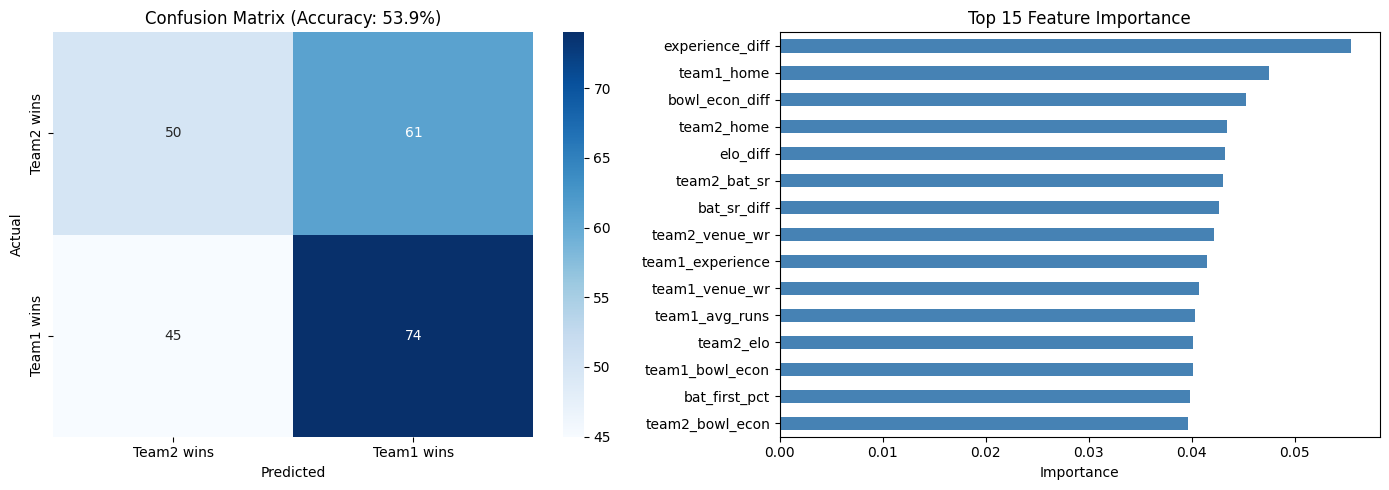

In [9]:
# ============================================================
# Step 9: Evaluate
# ============================================================

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.4f} ({acc*100:.1f}%)")
print(f"ROC-AUC:  {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Team2 wins', 'Team1 wins']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Team2 wins', 'Team1 wins'],
            yticklabels=['Team2 wins', 'Team1 wins'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (Accuracy: {acc:.1%})')

# Plot 2: Feature Importance (top 15)
importance = pd.Series(model.feature_importances_, index=feature_cols)
importance.nlargest(15).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## Step 10: Save Model & Artifacts

In [10]:
# ============================================================
# Step 10: Save model and everything needed for prediction
# ============================================================

os.makedirs('Models', exist_ok=True)

# Save the trained model
with open('Models/xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save feature column names (order matters for prediction)
with open('Models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

# Save final Elo ratings (will be starting point for 2026 predictions)
with open('Models/elo_ratings.pkl', 'wb') as f:
    pickle.dump(dict(elo_ratings), f)

# Save the alias map for team name normalization
with open('Models/alias_map.pkl', 'wb') as f:
    pickle.dump(alias_map, f)

# Save the match history (needed for form, H2H, venue calculations)
with open('Models/match_history.pkl', 'wb') as f:
    pickle.dump(match_history, f)

print("Saved to Models/:")
for f in os.listdir('Models'):
    size = os.path.getsize(f'Models/{f}') / 1024
    print(f"  {f} ({size:.1f} KB)")

Saved to Models/:
  alias_map.pkl (0.7 KB)
  elo_ratings.pkl (0.2 KB)
  feature_columns.pkl (0.4 KB)
  match_history.pkl (35.9 KB)
  xgb_model.pkl (387.3 KB)


## Step 11: Predict a Match

This is what you'll use for IPL 2026 predictions. Provide:
- `team1`, `team2` â€” team names (any format, will be normalized)
- `venue` â€” stadium name
- `toss_winner` â€” who won the toss
- `toss_decision` â€” "bat" or "field"
- `team1_xi`, `team2_xi` â€” list of 11 player names each

In [11]:
# ============================================================
# Step 11: Prediction function
# ============================================================

def predict_match(team1, team2, venue, toss_winner, toss_decision, team1_xi, team2_xi):
    """
    Predict match winner given pre-match inputs.
    Returns: predicted winner, team1 win probability, team2 win probability
    """
    # Normalize team names
    t1 = normalize_team(team1)
    t2 = normalize_team(team2)
    tw = normalize_team(toss_winner)
    
    # --- Compute features (same order as training) ---
    
    # Elo
    t1_elo = elo_ratings.get(t1, 1500)
    t2_elo = elo_ratings.get(t2, 1500)
    
    # Form & H2H (using full match history up to now)
    t1_form = get_team_form(t1, match_history, n=5)
    t2_form = get_team_form(t2, match_history, n=5)
    h2h_wr = get_h2h(t1, t2, match_history)
    
    # Venue
    t1_venue_wr, bat_first_pct = get_venue_stats(t1, venue, match_history)
    t2_venue_wr, _ = get_venue_stats(t2, venue, match_history)
    
    # Toss
    toss_is_t1 = 1 if tw == t1 else 0
    chose_bat = 1 if toss_decision == 'bat' else 0
    
    # Home
    t1_home = is_home(t1, venue)
    t2_home = is_home(t2, venue)
    
    # Player strength from provided XI
    t1_stats = [get_player_stats(p) for p in team1_xi]
    t2_stats = [get_player_stats(p) for p in team2_xi]
    
    t1_bat_sr = np.mean([s['batting_sr'] for s in t1_stats])
    t1_bowl_econ = np.mean([s['bowling_econ'] for s in t1_stats])
    t1_exp = np.mean([s['experience'] for s in t1_stats])
    t1_avg_runs = np.mean([s['avg_runs'] for s in t1_stats])
    
    t2_bat_sr = np.mean([s['batting_sr'] for s in t2_stats])
    t2_bowl_econ = np.mean([s['bowling_econ'] for s in t2_stats])
    t2_exp = np.mean([s['experience'] for s in t2_stats])
    t2_avg_runs = np.mean([s['avg_runs'] for s in t2_stats])
    
    # Build feature vector (MUST match feature_cols order)
    features = pd.DataFrame([{
        'team1_elo': t1_elo,
        'team2_elo': t2_elo,
        'elo_diff': t1_elo - t2_elo,
        'team1_form': t1_form,
        'team2_form': t2_form,
        'form_diff': t1_form - t2_form,
        'h2h_team1_wr': h2h_wr,
        'team1_venue_wr': t1_venue_wr,
        'team2_venue_wr': t2_venue_wr,
        'bat_first_pct': bat_first_pct,
        'toss_winner_is_team1': toss_is_t1,
        'toss_chose_bat': chose_bat,
        'team1_home': t1_home,
        'team2_home': t2_home,
        'team1_bat_sr': t1_bat_sr,
        'team1_bowl_econ': t1_bowl_econ,
        'team1_experience': t1_exp,
        'team1_avg_runs': t1_avg_runs,
        'team2_bat_sr': t2_bat_sr,
        'team2_bowl_econ': t2_bowl_econ,
        'team2_experience': t2_exp,
        'team2_avg_runs': t2_avg_runs,
        'bat_sr_diff': t1_bat_sr - t2_bat_sr,
        'bowl_econ_diff': t1_bowl_econ - t2_bowl_econ,
        'experience_diff': t1_exp - t2_exp,
    }])
    
    # Predict
    prob = model.predict_proba(features[feature_cols])[0]
    team1_prob = prob[1]
    team2_prob = prob[0]
    
    predicted_winner = team1 if team1_prob > 0.5 else team2
    
    print(f"{'='*50}")
    print(f"  {team1} vs {team2}")
    print(f"  Venue: {venue}")
    print(f"  Toss: {toss_winner} chose to {toss_decision}")
    print(f"{'='*50}")
    print(f"  Predicted Winner: {predicted_winner}")
    print(f"  {team1}: {team1_prob:.1%}")
    print(f"  {team2}: {team2_prob:.1%}")
    print(f"{'='*50}")
    
    return predicted_winner, team1_prob, team2_prob

## Step 12: Test Prediction

Try a sample prediction â€” MI vs CSK at Wankhede.

In [12]:
# ============================================================
# Step 12: Test with a sample match
# ============================================================

predict_match(
    team1="Mumbai Indians",
    team2="Chennai Super Kings",
    venue="Wankhede Stadium",
    toss_winner="Mumbai Indians",
    toss_decision="field",
    team1_xi=[
        "RG Sharma", "Ishan Kishan", "SA Yadav", "TH David",
        "Hardik Pandya", "TI de Bruyn", "PP Chawla", "JJ Bumrah",
        "Trent Boult", "Kumar Kartikeya", "R Goyal"
    ],
    team2_xi=[
        "RD Gaikwad", "DP Conway", "S Dube", "MS Dhoni",
        "RA Jadeja", "Shardul Thakur", "M Theekshana", "TU Deshpande",
        "Simarjeet Singh", "Mukesh Choudhary", "Matheesha Pathirana"
    ],
)

  Mumbai Indians vs Chennai Super Kings
  Venue: Wankhede Stadium
  Toss: Mumbai Indians chose to field
  Predicted Winner: Chennai Super Kings
  Mumbai Indians: 36.0%
  Chennai Super Kings: 64.0%


('Chennai Super Kings', np.float32(0.36025405), np.float32(0.63974595))

## Step 13: Detailed Performance Metrics

A deeper look at model quality beyond basic accuracy:
1. **Cross-validation** â€” is accuracy stable across folds?
2. **Log loss** â€” how good are the predicted probabilities?
3. **Calibration curve** â€” does 70% confidence actually mean 70% win rate?
4. **Precision-Recall curve**
5. **Per-team accuracy** â€” which teams does the model predict well?
6. **Confidence analysis** â€” accuracy at different confidence levels

In [13]:
# ============================================================
# Step 13a: Cross-Validation (5-fold)
# ============================================================
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric='logloss',
    ),
    X, y, cv=5, scoring='accuracy'
)

print("5-Fold Cross-Validation:")
print(f"  Fold scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean:  {cv_scores.mean():.4f}")
print(f"  Std:   {cv_scores.std():.4f}")
print(f"\n  â†’ If std is low (<0.03), the model is stable across different data splits.")

5-Fold Cross-Validation:
  Fold scores: ['0.5391', '0.5808', '0.4803', '0.5546', '0.4934']
  Mean:  0.5297
  Std:   0.0376

  â†’ If std is low (<0.03), the model is stable across different data splits.


In [14]:
# ============================================================
# Step 13b: Log Loss
# ============================================================
from sklearn.metrics import log_loss

logloss = log_loss(y_test, y_prob)
print(f"Log Loss: {logloss:.4f}")
print(f"\n  â†’ Lower is better. Perfect = 0, random guessing = 0.693.")
print(f"  â†’ Our model: {'Good' if logloss < 0.65 else 'Needs improvement'} (threshold: 0.65)")

Log Loss: 0.7377

  â†’ Lower is better. Perfect = 0, random guessing = 0.693.
  â†’ Our model: Needs improvement (threshold: 0.65)


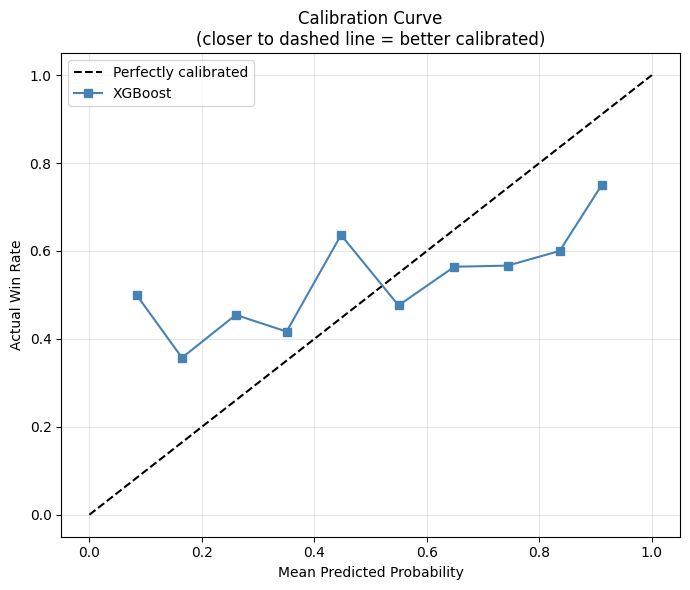

â†’ If the blue line hugs the dashed line, the model's probabilities are trustworthy.
  e.g., when it says 70% chance, the team actually wins ~70% of the time.


In [15]:
# ============================================================
# Step 13c: Calibration Curve
# ============================================================
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

# Compute calibration: bin predictions into 10 buckets
fraction_positive, mean_predicted = calibration_curve(y_test, y_prob, n_bins=10)

# Perfect calibration line
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')

# Our model
ax.plot(mean_predicted, fraction_positive, 's-', color='steelblue', label='XGBoost')

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Actual Win Rate')
ax.set_title('Calibration Curve\n(closer to dashed line = better calibrated)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("â†’ If the blue line hugs the dashed line, the model's probabilities are trustworthy.")
print("  e.g., when it says 70% chance, the team actually wins ~70% of the time.")

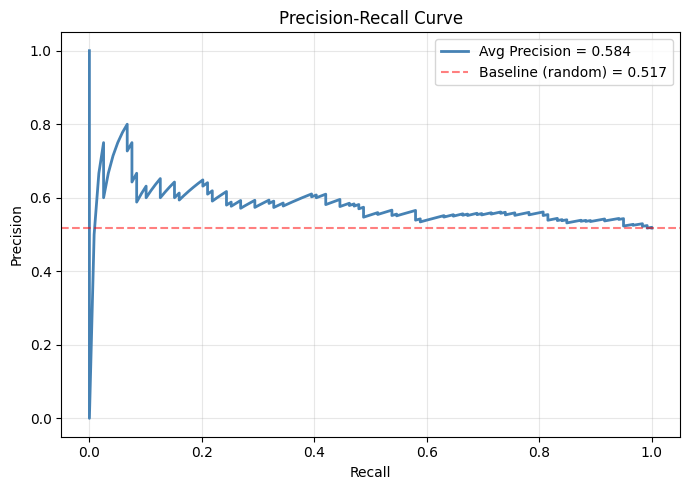

Average Precision: 0.5841
â†’ Higher is better. Baseline (random) = proportion of Team1 wins in test set.


In [16]:
# ============================================================
# Step 13d: Precision-Recall Curve
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', lw=2,
        label=f'Avg Precision = {avg_precision:.3f}')
ax.axhline(y=y_test.mean(), color='red', linestyle='--', alpha=0.5,
           label=f'Baseline (random) = {y_test.mean():.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision: {avg_precision:.4f}")
print("â†’ Higher is better. Baseline (random) = proportion of Team1 wins in test set.")

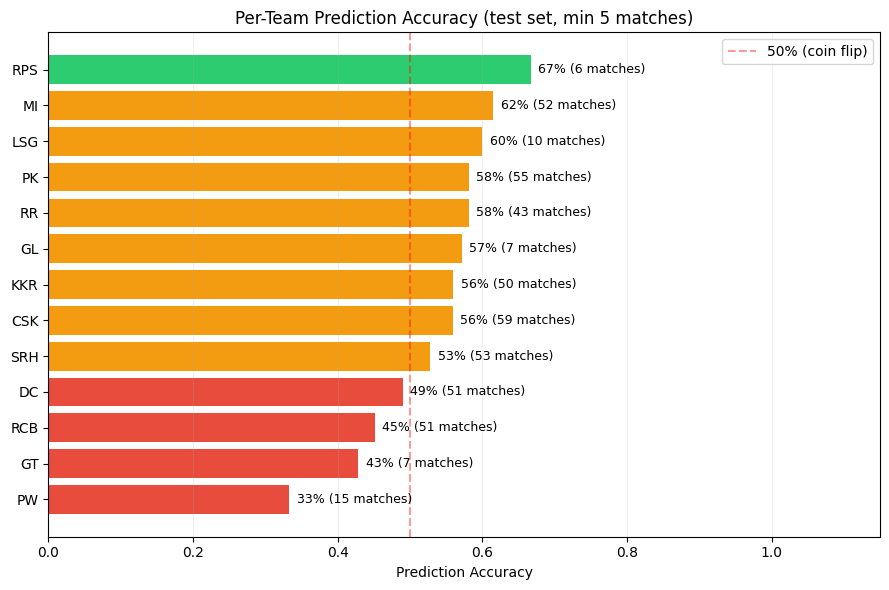

â†’ Green = model predicts well (â‰¥65%), Yellow = decent (50-65%), Red = poor (<50%)


In [17]:
# ============================================================
# Step 13e: Per-Team Accuracy
# ============================================================

# We need team names alongside test predictions
# Get the test set indices and map back to matches
test_indices = X_test.index.tolist()

team_results = []
for idx in test_indices:
    row = matches.iloc[idx]
    actual = y_test.loc[idx]
    predicted = 1 if y_prob[list(X_test.index).index(idx)] > 0.5 else 0
    correct = int(actual == predicted)
    
    # Both teams in this match get a record
    team_results.append({'team': row['team1'], 'correct': correct})
    team_results.append({'team': row['team2'], 'correct': correct})

team_df = pd.DataFrame(team_results)
team_acc = team_df.groupby('team').agg(
    matches=('correct', 'count'),
    correct=('correct', 'sum')
).reset_index()
team_acc['accuracy'] = team_acc['correct'] / team_acc['matches']
team_acc = team_acc.sort_values('accuracy', ascending=True)

# Only show teams with at least 5 test matches
team_acc_filtered = team_acc[team_acc['matches'] >= 5]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if a < 0.5 else '#2ecc71' if a >= 0.65 else '#f39c12'
          for a in team_acc_filtered['accuracy']]
bars = ax.barh(team_acc_filtered['team'], team_acc_filtered['accuracy'], color=colors)

# Add match count labels
for bar, matches_count in zip(bars, team_acc_filtered['matches']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.0%} ({matches_count} matches)',
            va='center', fontsize=9)

ax.set_xlabel('Prediction Accuracy')
ax.set_title('Per-Team Prediction Accuracy (test set, min 5 matches)')
ax.set_xlim(0, 1.15)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4, label='50% (coin flip)')
ax.legend()
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

print("â†’ Green = model predicts well (â‰¥65%), Yellow = decent (50-65%), Red = poor (<50%)")

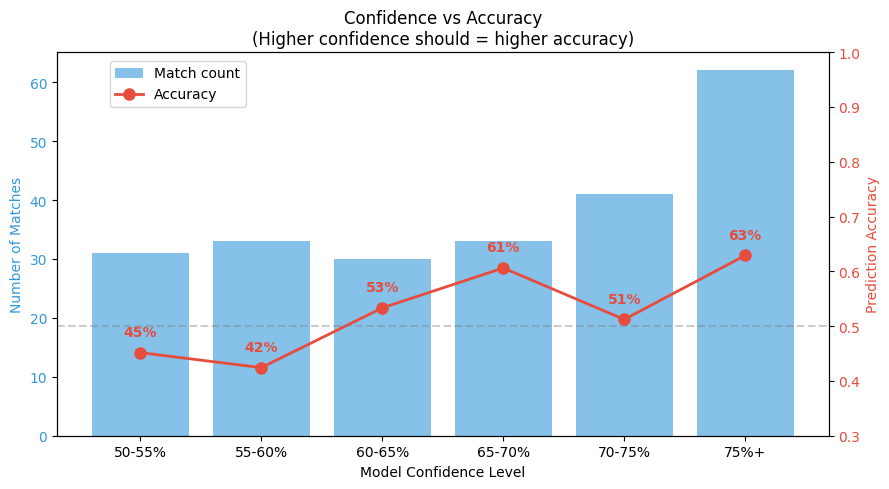

â†’ Ideally accuracy goes UP as confidence increases.
  This tells you how much to trust the model's strong predictions.


In [18]:
# ============================================================
# Step 13f: Confidence Analysis
# ============================================================

# How accurate is the model at different confidence levels?
# "Confidence" = how far the predicted probability is from 50%

confidence = np.maximum(y_prob, 1 - y_prob)  # always the higher prob (winner side)
y_pred_test = (y_prob > 0.5).astype(int)
correct = (y_pred_test == y_test.values).astype(int)

# Define confidence buckets
bins = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 1.0]
labels = ['50-55%', '55-60%', '60-65%', '65-70%', '70-75%', '75%+']

conf_bucket = pd.cut(confidence, bins=bins, labels=labels, include_lowest=True)

conf_df = pd.DataFrame({'bucket': conf_bucket, 'correct': correct})
conf_stats = conf_df.groupby('bucket', observed=False).agg(
    matches=('correct', 'count'),
    accuracy=('correct', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 5))

# Bar chart: number of matches per bucket
color_bars = '#3498db'
color_line = '#e74c3c'

bars = ax1.bar(conf_stats['bucket'], conf_stats['matches'],
               color=color_bars, alpha=0.6, label='Match count')
ax1.set_xlabel('Model Confidence Level')
ax1.set_ylabel('Number of Matches', color=color_bars)
ax1.tick_params(axis='y', labelcolor=color_bars)

# Line chart: accuracy per bucket (second y-axis)
ax2 = ax1.twinx()
ax2.plot(conf_stats['bucket'], conf_stats['accuracy'],
         'o-', color=color_line, lw=2, markersize=8, label='Accuracy')
ax2.set_ylabel('Prediction Accuracy', color=color_line)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0.3, 1.0)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)

# Add accuracy labels on line
for i, row in conf_stats.iterrows():
    if row['matches'] > 0:
        ax2.annotate(f"{row['accuracy']:.0%}",
                     (i, row['accuracy']),
                     textcoords="offset points", xytext=(0, 12),
                     ha='center', fontsize=10, fontweight='bold', color=color_line)

ax1.set_title('Confidence vs Accuracy\n(Higher confidence should = higher accuracy)')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

print("â†’ Ideally accuracy goes UP as confidence increases.")
print("  This tells you how much to trust the model's strong predictions.")

In [19]:
# ============================================================
# Step 13g: Summary Dashboard
# ============================================================

print("=" * 55)
print("       MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  Accuracy:           {acc:.1%}")
print(f"  ROC-AUC:            {auc:.4f}")
print(f"  Log Loss:           {logloss:.4f}")
print(f"  Avg Precision:      {avg_precision:.4f}")
print(f"  CV Mean Accuracy:   {cv_scores.mean():.1%} Â± {cv_scores.std():.1%}")
print("=" * 55)

# High-confidence accuracy
high_conf_mask = confidence >= 0.60
if high_conf_mask.sum() > 0:
    high_conf_acc = correct[high_conf_mask].mean()
    print(f"  High-conf (â‰¥60%) accuracy: {high_conf_acc:.1%}  ({high_conf_mask.sum()} matches)")

low_conf_mask = confidence < 0.55
if low_conf_mask.sum() > 0:
    low_conf_acc = correct[low_conf_mask].mean()
    print(f"  Low-conf  (<55%) accuracy: {low_conf_acc:.1%}  ({low_conf_mask.sum()} matches)")

print("=" * 55)

       MODEL PERFORMANCE SUMMARY
  Accuracy:           53.9%
  ROC-AUC:            0.5733
  Log Loss:           0.7377
  Avg Precision:      0.5841
  CV Mean Accuracy:   53.0% Â± 3.8%
  High-conf (â‰¥60%) accuracy: 57.8%  (166 matches)
  Low-conf  (<55%) accuracy: 45.2%  (31 matches)
